In [12]:
# Import libraries
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import minimize
from scipy.special import j0

In [13]:
# Input files and global parameters
SF_EDGE_LIST = "N200_y2.4_small_hubs.edgelist"
ER_EDGE_LIST = "N200_Erdos_Renyi_Graph_0.04.edgelist"

B_BACKGROUND = 5.0
J_R = -1.0
J_I = 0.0
COS_THETA = -1.0
EPS_BETWEENNESS = 1e-12

BOUNDS_B = (0.0, 20.0)
N_RESTARTS = 10
SEED = 42
XATOL = 1e-4
FATOL = 1e-4

In [14]:
# Load graphs
def load_graph_from_edgelist(path):
    G_raw = nx.read_edgelist(path)
    G = nx.convert_node_labels_to_integers(G_raw)
    return G

def graph_statistics(G, name):
    A = nx.to_numpy_array(G)
    degrees = A.sum(axis=1)
    print(name)
    print("N =", G.number_of_nodes())
    print("k_min =", int(degrees.min()))
    print("k_max =", int(degrees.max()))
    print("<k> =", np.mean(degrees))
    print("zeta =", np.sum(degrees**2) / np.sum(degrees))
    print()

G_SF = load_graph_from_edgelist(SF_EDGE_LIST)
G_ER = load_graph_from_edgelist(ER_EDGE_LIST)
graph_statistics(G_SF, "Scale-free graph")
graph_statistics(G_ER, "Erdos-Renyi graph")

Scale-free graph
N = 200
k_min = 3
k_max = 71
<k> = 7.75
zeta = 18.96258064516129

Erdos-Renyi graph
N = 200
k_min = 2
k_max = 15
<k> = 7.42
zeta = 8.214285714285714



In [15]:
# Core Floquet functions
def top_degree_hubs(G, k):
    A = nx.to_numpy_array(G)
    degrees = A.sum(axis=1)
    hubs = np.argsort(degrees)[-k:][::-1]
    return hubs, degrees

def build_B_all(N, hub_indices, B_hubs, B_background=B_BACKGROUND):
    B_all = np.ones(N) * B_background
    for idx, hub in enumerate(hub_indices):
        B_all[int(hub)] = B_hubs[idx]
    return B_all

def effective_operator(G, B, J_r=J_R, J_i=J_I, cos_theta=COS_THETA):
    A = nx.to_numpy_array(G)
    coupling = -J_r - 1j * cos_theta * J_i
    return coupling * A * j0(B[:, None] - B[None, :])

def spectrum_and_ipr(M):
    eigenvalues, eigenvectors = np.linalg.eig(M)
    idx = np.argsort(eigenvalues.real)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    ipr_values = []
    for n in range(eigenvectors.shape[1]):
        prob = np.abs(eigenvectors[:, n]) ** 2
        norm = prob.sum()
        if norm > 0:
            prob = prob / norm
            ipr_values.append(np.sum(prob ** 2))
        else:
            ipr_values.append(0.0)
    return eigenvalues, np.array(ipr_values)

In [16]:
# Hub-suppression optimization
def suppress_k_hubs(G, k_hubs, J_r=J_R, J_i=J_I, cos_theta=COS_THETA, B_background=B_BACKGROUND, bounds_B=BOUNDS_B, n_restarts=N_RESTARTS,seed=SEED, verbose=True):
    N = G.number_of_nodes()
    hub_indices, degrees = top_degree_hubs(G, k_hubs)
    coupling_abs = abs(-J_r - 1j * cos_theta * J_i)
    if verbose:
        print(f"Suppressing {k_hubs} hubs:", hub_indices)
        print("Hub degrees:", degrees[hub_indices])
    edge_hubs = []
    edge_neighbors = []
    hub_to_var = {int(hub): idx for idx, hub in enumerate(hub_indices)}
    for hub in hub_indices:
        for nbr in G.neighbors(int(hub)):
            edge_hubs.append(int(hub))
            edge_neighbors.append(int(nbr))
    edge_hubs = np.asarray(edge_hubs, dtype=int)
    edge_neighbors = np.asarray(edge_neighbors, dtype=int)
    edge_hub_vars = np.asarray([hub_to_var[int(h)] for h in edge_hubs], dtype=int)
    neighbor_is_controlled = np.asarray([int(n) in hub_to_var for n in edge_neighbors], dtype=bool)
    neighbor_vars = np.asarray([hub_to_var[int(n)] if int(n) in hub_to_var else -1 for n in edge_neighbors], dtype=int)

    def objective(B_hubs):
        B_hub_side = B_hubs[edge_hub_vars]
        B_neighbor_side = np.full(edge_neighbors.shape, B_background, dtype=float)
        if np.any(neighbor_is_controlled):
            B_neighbor_side[neighbor_is_controlled] = B_hubs[neighbor_vars[neighbor_is_controlled]]
        return coupling_abs * np.sum(np.abs(j0(np.abs(B_hub_side - B_neighbor_side))))
    rng = np.random.default_rng(seed)
    best_res = None
    best_fun = np.inf
    bounds = [bounds_B] * k_hubs
    for restart in range(n_restarts):
        x0 = rng.uniform(bounds_B[0], bounds_B[1], size=k_hubs)
        res = minimize(
            objective,
            x0,
            method="Nelder-Mead",
            bounds=bounds,
            options={"maxiter": 1000 * k_hubs, "xatol": XATOL, "fatol": FATOL, "disp": False})
        if verbose:
            print(f"restart {restart}: objective = {res.fun:.8f}")
        if res.fun < best_fun:
            best_fun = res.fun
            best_res = res
    B_hubs_opt = best_res.x
    B_opt = build_B_all(N, hub_indices, B_hubs_opt, B_background=B_background)
    if verbose:
        print("Best objective:", best_fun)
        for hub, B_val in zip(hub_indices, B_hubs_opt):
            print(f"hub {int(hub):4d}: B = {B_val:.8f}")
        print()
    return B_opt, hub_indices, best_fun

In [17]:
# Plotting style and spectral/IPR plots
def set_plot_style():
    font = {"weight": "bold", "size": 18}
    plt.rc("font", **font)
    plt.rc("axes", labelsize=18)
    plt.rc("xtick", labelsize=18)
    plt.rc("ytick", labelsize=18)

def plot_rho_from_B(G, B_after, xlim=(-10, 20), ylim=(0, 0.3), bins_real=None, figsize=(8, 6), before_label="Before renormalization", after_label="After renormalization",):
    if bins_real is None:
        bins_real = np.linspace(-20, 20, 100)
    N = G.number_of_nodes()
    B_before = np.ones(N) * B_BACKGROUND
    omega_before, _ = spectrum_and_ipr(effective_operator(G, B_before))
    omega_after, _ = spectrum_and_ipr(effective_operator(G, B_after))
    plt.figure(figsize=figsize)
    plt.hist(omega_before.real, bins=bins_real, alpha=0.6, label=before_label, color="red", density=True)
    plt.hist(omega_after.real, bins=bins_real, alpha=0.4, label=after_label, color="blue", density=True)
    set_plot_style()
    plt.xlabel(r"$\omega$", fontsize=24, fontweight="normal")
    plt.ylabel(r"$\rho(\omega)$", fontsize=24, fontweight="normal")
    plt.ylim(*ylim)
    plt.xlim(*xlim)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_ipr_from_B(G, B_after, xlim=(-10, 20), ylim=(0, 0.25), figsize=(10, 6), title=None, before_label="Before renormalization", after_label="After renormalization"):
    N = G.number_of_nodes()
    B_before = np.ones(N) * B_BACKGROUND
    eigenvalues_before, ipr_before = spectrum_and_ipr(effective_operator(G, B_before))
    eigenvalues_after, ipr_after = spectrum_and_ipr(effective_operator(G, B_after))
    plt.figure(figsize=figsize)
    plt.scatter(eigenvalues_before.real, ipr_before, s=30, c="red", alpha=0.7, label=before_label)
    plt.scatter(eigenvalues_after.real, ipr_after, s=30, c="blue", alpha=0.3, label=after_label)
    set_plot_style()
    plt.xlabel(r"$\omega$", fontsize=24, fontweight="normal")
    plt.ylabel("IPR", fontsize=24, fontweight="normal")
    plt.grid(True, alpha=0.3)
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    if title is not None:
        plt.title(title, fontsize=18, fontweight="normal")
    plt.legend()
    plt.tight_layout()
    plt.show()

Suppressing 1 hubs: [4]
Hub degrees: [71.]
restart 0: objective = 0.00014943
restart 1: objective = 0.00030783
restart 2: objective = 0.00008985
restart 3: objective = 0.00009915
restart 4: objective = 0.00008845
restart 5: objective = 0.00006891
restart 6: objective = 0.00007781
restart 7: objective = 0.00018213
restart 8: objective = 0.00005579
restart 9: objective = 0.00007332
Best objective: 5.578887080793408e-05
hub    4: B = 2.59517293



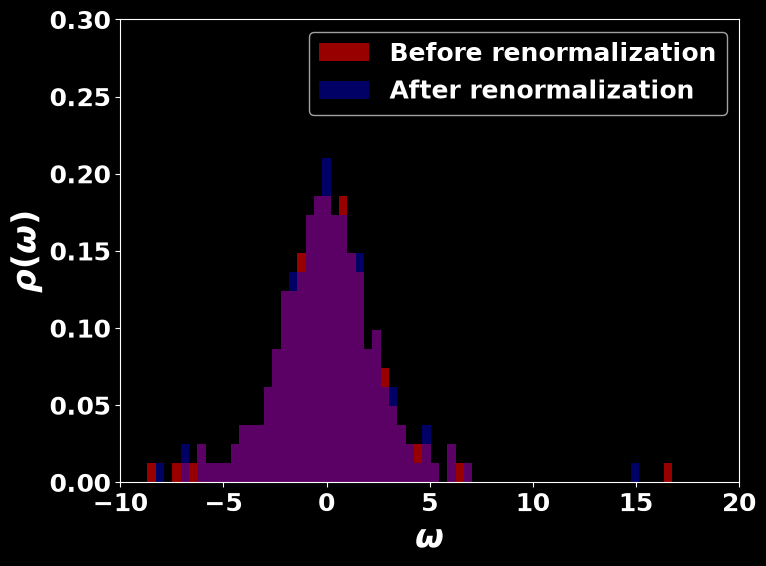

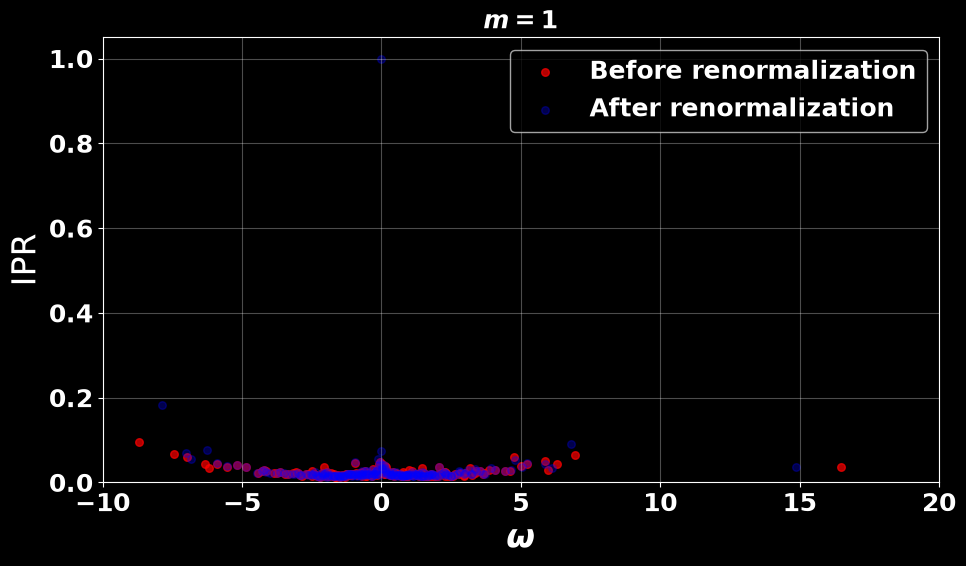

Suppressing 1 hubs: [23]
Hub degrees: [15.]
restart 0: objective = 0.00005079
restart 1: objective = 0.00006503
restart 2: objective = 0.00006467
restart 3: objective = 0.00006571
restart 4: objective = 0.00007084
restart 5: objective = 0.00006456
restart 6: objective = 0.00001644
restart 7: objective = 0.00012212
restart 8: objective = 0.00001866
restart 9: objective = 0.00001959
Best objective: 1.643928634530925e-05
hub   23: B = 16.79152972



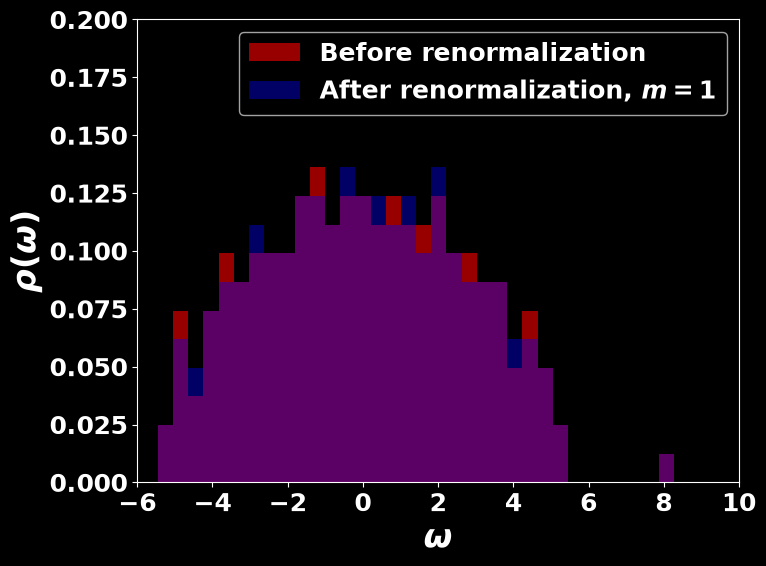

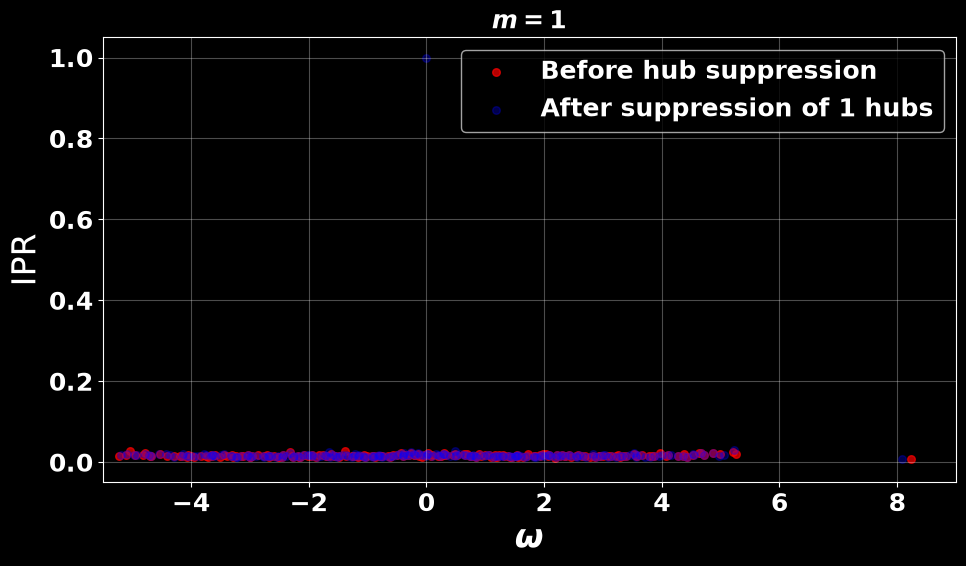

In [18]:
# Single-hub suppression
B_SF_M1, HUBS_SF_M1, OBJ_SF_M1 = suppress_k_hubs(G_SF, k_hubs=1)
plot_rho_from_B(G_SF, B_SF_M1, xlim=(-10, 20), ylim=(0, 0.3))
plot_ipr_from_B(G_SF, B_SF_M1, xlim=(-10, 20), ylim=(0, 1.05), title=r"$m=1$")
B_ER_M1, HUBS_ER_M1, OBJ_ER_M1 = suppress_k_hubs(G_ER, k_hubs=1)
plot_rho_from_B(G_ER, B_ER_M1, xlim=(-6, 10), ylim=(0, 0.2), after_label=r"After renormalization, $m=1$",)
plot_ipr_from_B(G_ER, B_ER_M1, xlim=(-5.5, 9), ylim=(-0.05, 1.05), title=r"$m=1$", before_label="Before hub suppression", after_label="After suppression of 1 hubs")

Suppressing 20 hubs: [ 4  1  5 64 38 48 43 39 34 46 85 69 18 70 44 83 32 28 90 36]
Hub degrees: [71. 66. 44. 43. 38. 37. 36. 26. 25. 25. 24. 24. 24. 22. 20. 19. 17. 17.
 15. 14.]
restart 0: objective = 89.59901038
restart 1: objective = 80.38265896
restart 2: objective = 90.26077682
restart 3: objective = 86.51115137
restart 4: objective = 82.15563643
restart 5: objective = 96.19340278
restart 6: objective = 96.71531576
restart 7: objective = 76.63022438
restart 8: objective = 97.41057109
restart 9: objective = 96.38783155
Best objective: 76.63022438061486
hub    4: B = 10.52007814
hub    1: B = 10.51991312
hub    5: B = 16.79153786
hub   64: B = 13.65372054
hub   38: B = 10.51780778
hub   48: B = 7.40503844
hub   43: B = 7.42270869
hub   39: B = 7.68179178
hub   34: B = 7.41585570
hub   46: B = 0.38753859
hub   85: B = 16.79152083
hub   69: B = 16.78955328
hub   18: B = 2.36569881
hub   70: B = 10.22728891
hub   44: B = 2.52594013
hub   83: B = 13.10731283
hub   32: B = 4.43629520
hub

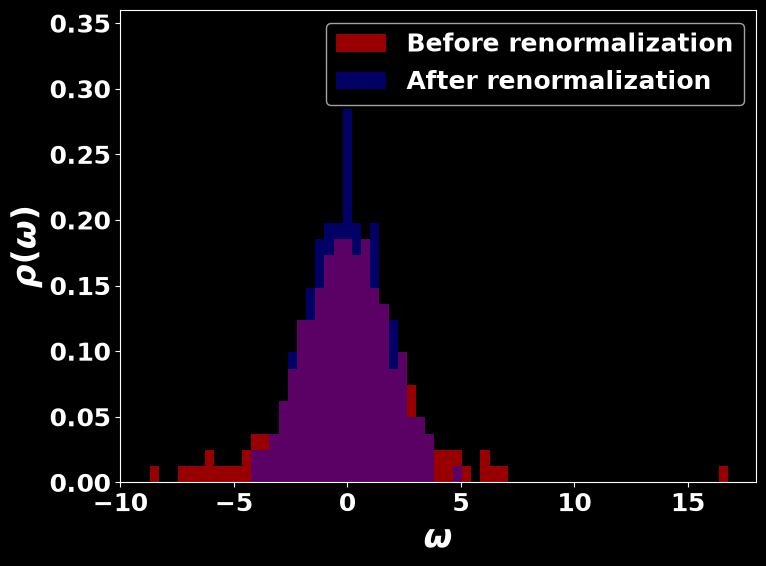

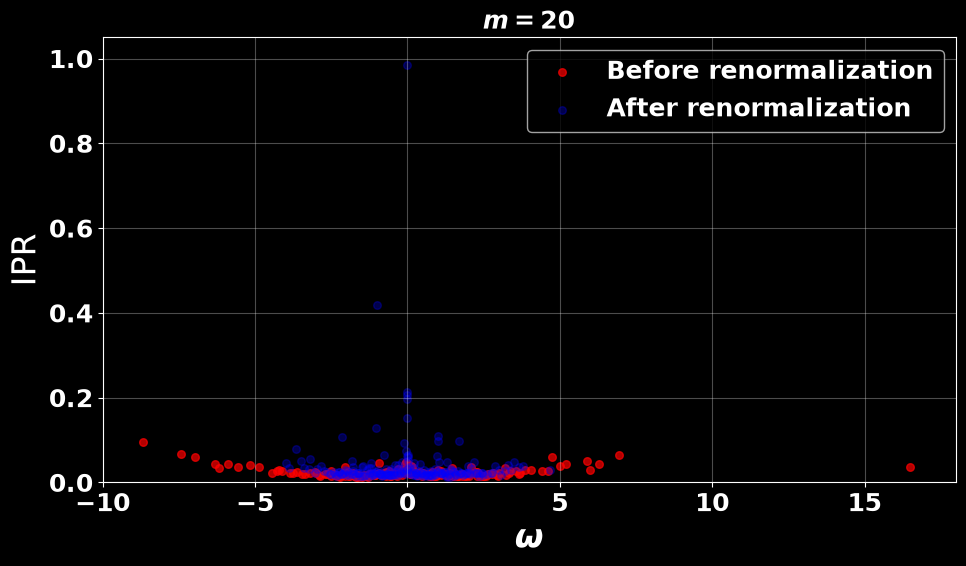

Suppressing 20 hubs: [ 23 110  14  30  90 164  16  99 114   1   2  74  52  50  54  44  39 130
 140   5]
Hub degrees: [15. 15. 14. 14. 13. 12. 12. 12. 12. 11. 11. 11. 11. 11. 11. 11. 11. 11.
 11. 11.]
restart 0: objective = 18.54714940
restart 1: objective = 26.86326142
restart 2: objective = 14.05011141
restart 3: objective = 22.24818889
restart 4: objective = 18.33659698
restart 5: objective = 17.23170415
restart 6: objective = 22.79413001
restart 7: objective = 30.03471073
restart 8: objective = 26.32431977
restart 9: objective = 31.24646708
Best objective: 14.050111408550885
hub   23: B = 7.40482048
hub  110: B = 17.48536000
hub   14: B = 13.65372950
hub   30: B = 7.41087277
hub   90: B = 15.74894557
hub  164: B = 16.40941284
hub   16: B = 7.40482997
hub   99: B = 7.40482458
hub  114: B = 13.65368106
hub    1: B = 2.62609078
hub    2: B = 2.59520004
hub   74: B = 0.14600103
hub   52: B = 16.53769522
hub   50: B = 13.65373305
hub   54: B = 13.65679775
hub   44: B = 16.79155586
hub   

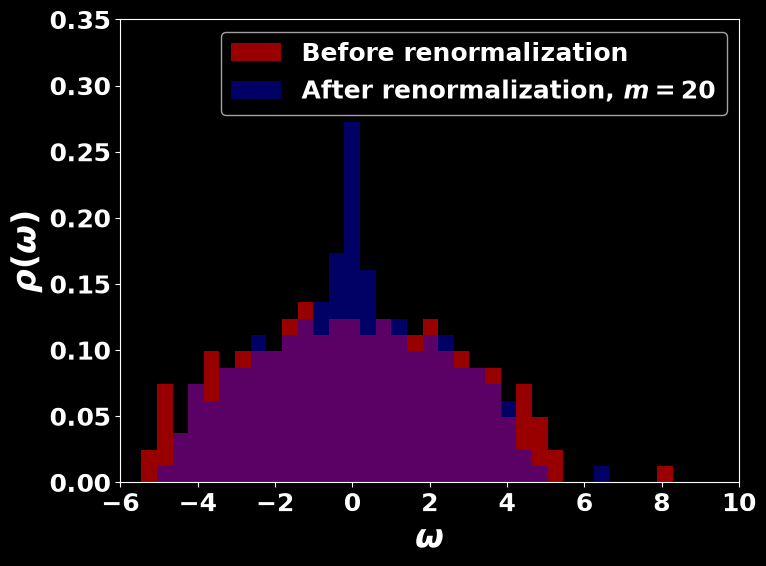

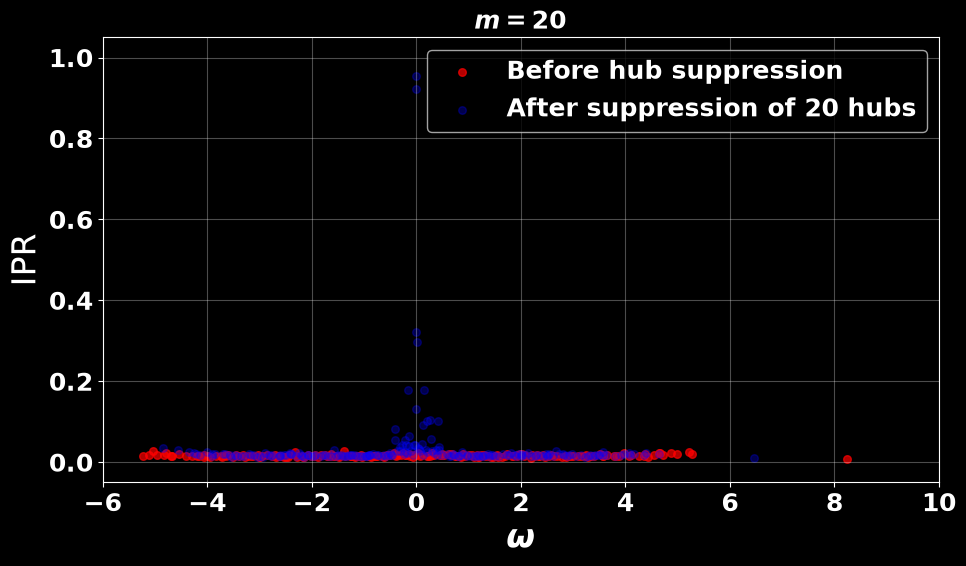

In [19]:
# Suppression of 20 hubs
B_SF_M20, HUBS_SF_M20, OBJ_SF_M20 = suppress_k_hubs(G_SF, k_hubs=20)
plot_rho_from_B(G_SF, B_SF_M20, xlim=(-10, 18), ylim=(0, 0.36))
plot_ipr_from_B(G_SF, B_SF_M20, xlim=(-10, 18), ylim=(0, 1.05), title=r"$m=20$")

B_ER_M20, HUBS_ER_M20, OBJ_ER_M20 = suppress_k_hubs(G_ER, k_hubs=20)
plot_rho_from_B(G_ER, B_ER_M20, xlim=(-6, 10), ylim=(0, 0.35), after_label=r"After renormalization, $m=20$")
plot_ipr_from_B(G_ER, B_ER_M20, xlim=(-6, 10),  ylim=(-0.05, 1.05), title=r"$m=20$", before_label="Before hub suppression", after_label="After suppression of 20 hubs")

Suppressing 10 hubs: [ 4  1  5 64 38 48 43 39 34 46]
Hub degrees: [71. 66. 44. 43. 38. 37. 36. 26. 25. 25.]
restart 0: objective = 32.66454512
restart 1: objective = 30.92723188
restart 2: objective = 26.51442925
restart 3: objective = 20.51412896
restart 4: objective = 54.41887668
restart 5: objective = 40.68499800
restart 6: objective = 30.75409300
restart 7: objective = 61.38239032
restart 8: objective = 35.76034904
restart 9: objective = 29.88683921
Best objective: 20.514128964922158
hub    4: B = 13.66308047
hub    1: B = 19.95551363
hub    5: B = 7.40482587
hub   64: B = 7.40482687
hub   38: B = 10.52155988
hub   48: B = 2.59519510
hub   43: B = 2.65825310
hub   39: B = 10.58233633
hub   34: B = 2.59593280
hub   46: B = 13.66643611



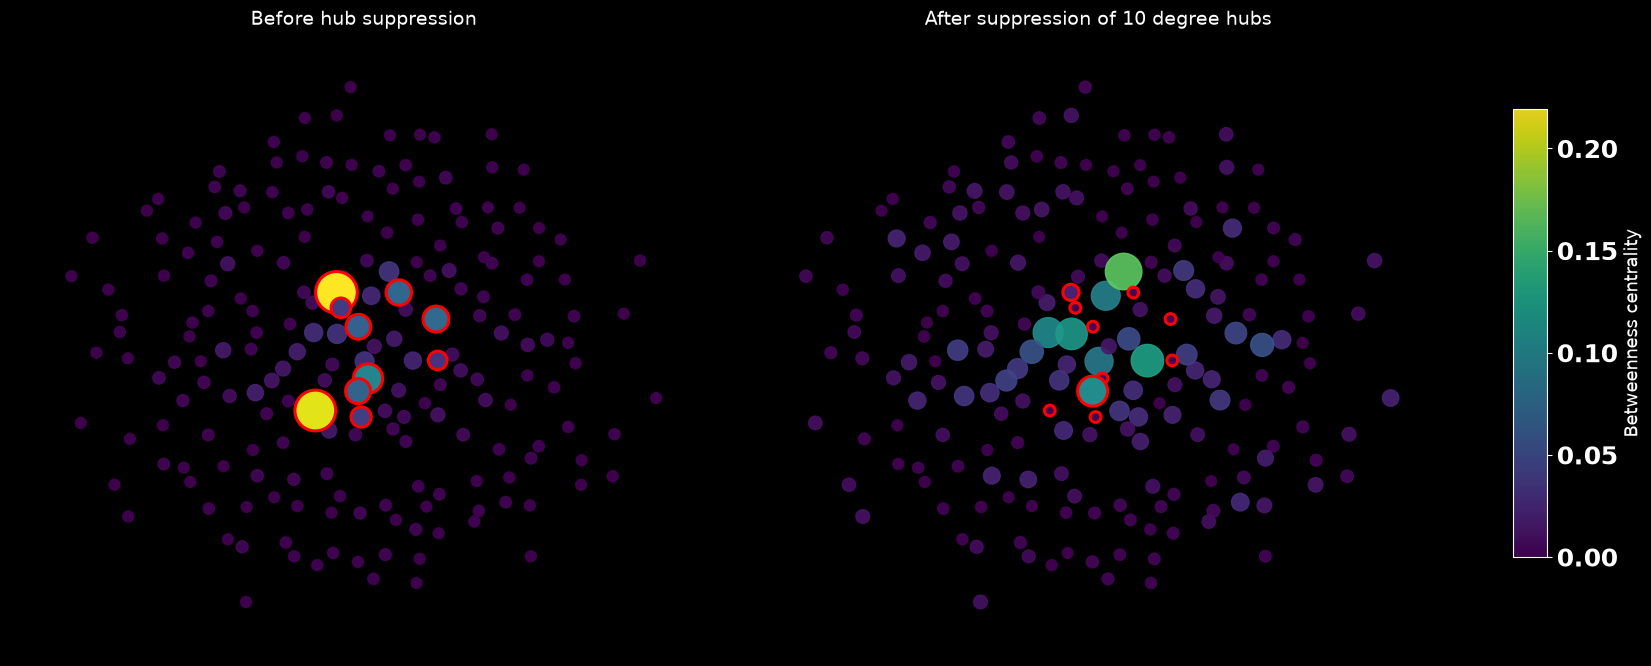

In [20]:
# Betweenness centrality before and after suppression of 10 hubs
def effective_weighted_graph_for_betweenness(G, B, eps=EPS_BETWEENNESS):
    G_eff = G.copy()
    for i, j in G_eff.edges():
        coupling = abs(j0(B[int(i)] - B[int(j)]))
        G_eff[i][j]["coupling"] = coupling
        G_eff[i][j]["weight"] = 1.0 / (coupling + eps)
    return G_eff

def plot_betweenness_before_after(G, B_after, hub_indices, layout="kamada", seed=42, node_size_min=60, node_size_max=900):
    nodes = list(G.nodes())
    bc_before_dict = nx.betweenness_centrality(G, normalized=True, weight=None)
    G_after = effective_weighted_graph_for_betweenness(G, B_after)
    bc_after_dict = nx.betweenness_centrality(G_after, normalized=True, weight="weight")
    bc_before = np.array([bc_before_dict[v] for v in nodes])
    bc_after = np.array([bc_after_dict[v] for v in nodes])
    bc_max = max(bc_before.max(), bc_after.max())
    sizes_before = node_size_min + (node_size_max - node_size_min) * bc_before / bc_max
    sizes_after = node_size_min + (node_size_max - node_size_min) * bc_after / bc_max
    if layout == "kamada":
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)
    fig, axes = plt.subplots(1, 2, figsize=(17, 7))
    panels = [(axes[0], G, bc_before, sizes_before, "Before hub suppression"),
        (axes[1], G_after, bc_after, sizes_after, "After suppression of 10 degree hubs")]
    nodes_drawn = None
    for ax, graph, bc_values, node_sizes, title in panels:
        nx.draw_networkx_edges(graph, pos, ax=ax, alpha=0.15, width=0.6)
        nodes_drawn = nx.draw_networkx_nodes(graph, pos, ax=ax,node_color=bc_values, node_size=node_sizes, cmap=cm.viridis, vmin=0, vmax=bc_max, alpha=0.9)
        nx.draw_networkx_nodes(graph, pos, ax=ax, nodelist=list(hub_indices), node_color=[bc_values[nodes.index(v)] for v in hub_indices], node_size=[node_sizes[nodes.index(v)] for v in hub_indices], cmap=cm.viridis, vmin=0, vmax=bc_max, edgecolors="red", linewidths=2.2)
        ax.set_title(title, fontsize=14, fontweight="normal")
        ax.axis("off")
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    cax = fig.add_axes([0.90, 0.18, 0.02, 0.64])
    cbar = fig.colorbar(nodes_drawn, cax=cax)
    cbar.set_label("Betweenness centrality", fontsize=13)
    plt.show()
    return bc_before, bc_after, G_after

B_SF_M10, HUBS_SF_M10, OBJ_SF_M10 = suppress_k_hubs(G_SF, k_hubs=10)
bc_before, bc_after, G_SF_M10_WEIGHTED = plot_betweenness_before_after(G_SF, B_SF_M10, HUBS_SF_M10)

Reactivated hub: 4
B before reactivation: 13.663080466452813
B after reactivation: 15.135047222515794
Restored strength: 17.858839780453817


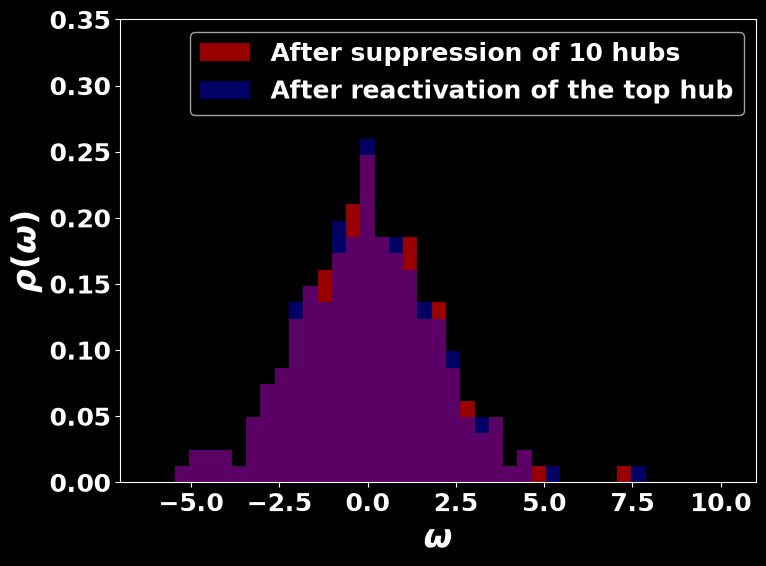

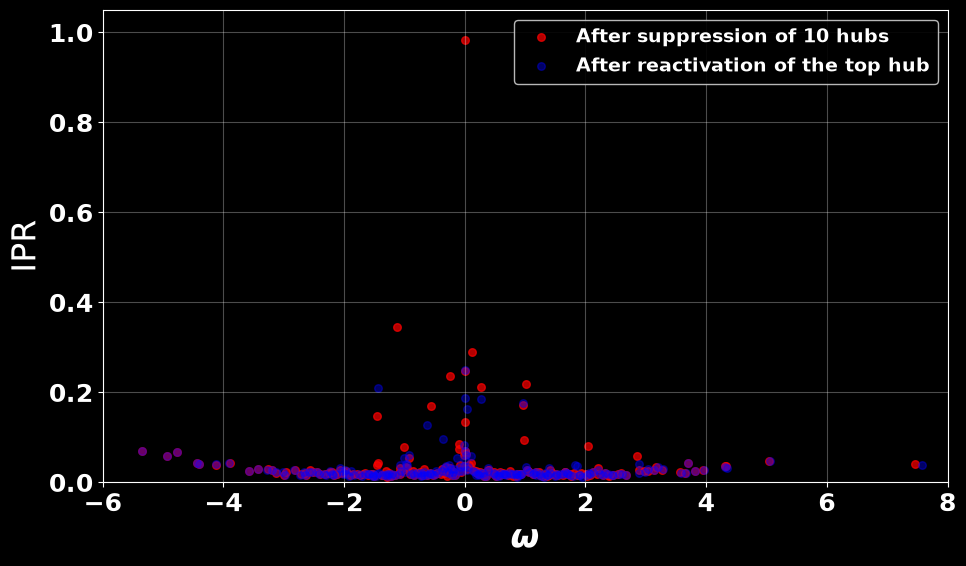

In [21]:
# Suppression of 10 hubs followed by reactivation of the top hub
def reactivate_top_hub_after_suppression(G, B_supp, hub_indices, J_r=J_R, J_i=J_I, cos_theta=COS_THETA, bounds_B=BOUNDS_B,):
    A = nx.to_numpy_array(G)
    coupling_abs = abs(-J_r - 1j * cos_theta * J_i)
    target_hub = int(hub_indices[0])
    target_neighbors = np.nonzero(A[target_hub])[0]

    def objective_reactivation(B_target_array):
        B_temp = B_supp.copy()
        B_temp[target_hub] = B_target_array[0]
        total_strength = 0.0
        for j in target_neighbors:
            total_strength += abs(coupling_abs * j0(abs(B_temp[target_hub] - B_temp[int(j)])))
        return -total_strength
    res = minimize(objective_reactivation, x0=np.array([B_supp[target_hub]]), method="Nelder-Mead", bounds=[bounds_B], options={"maxiter": 500, "xatol": XATOL, "fatol": FATOL, "disp": False})
    B_react = B_supp.copy()
    B_react[target_hub] = res.x[0]
    print("Reactivated hub:", target_hub)
    print("B before reactivation:", B_supp[target_hub])
    print("B after reactivation:", B_react[target_hub])
    print("Restored strength:", -res.fun)
    return B_react, target_hub, -res.fun

def plot_reactivation_rho(G, B_suppressed, B_reactivated):
    omega_supp, _ = spectrum_and_ipr(effective_operator(G, B_suppressed))
    omega_react, _ = spectrum_and_ipr(effective_operator(G, B_reactivated))
    bins_real = np.linspace(-20, 20, 100)
    plt.figure(figsize=(8, 6))
    plt.hist(omega_supp.real, bins=bins_real, density=True, alpha=0.6, color="red", label="After suppression of 10 hubs")
    plt.hist(omega_react.real, bins=bins_real, density=True, alpha=0.4, color="blue", label="After reactivation of the top hub")
    set_plot_style()
    plt.xlabel(r"$\omega$", fontsize=24, fontweight="normal")
    plt.ylabel(r"$\rho(\omega)$", fontsize=24, fontweight="normal")
    plt.xlim(-7, 11)
    plt.ylim(0, 0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_reactivation_ipr(G, B_suppressed, B_reactivated):
    eigenvalues_supp, ipr_supp = spectrum_and_ipr(effective_operator(G, B_suppressed))
    eigenvalues_react, ipr_react = spectrum_and_ipr(effective_operator(G, B_reactivated))
    plt.figure(figsize=(10, 6))
    plt.scatter(eigenvalues_supp.real, ipr_supp, s=30, c="red", alpha=0.7, label="After suppression of 10 hubs")
    plt.scatter(eigenvalues_react.real, ipr_react, s=30, c="blue", alpha=0.4, label="After reactivation of the top hub")
    set_plot_style()
    plt.xlabel(r"$\omega$", fontsize=24, fontweight="normal")
    plt.ylabel("IPR", fontsize=24, fontweight="normal")
    plt.grid(True, alpha=0.3)
    plt.xlim(-6, 8)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=14, framealpha=0.9)
    plt.tight_layout()
    plt.show()

B_SF_REACT, TARGET_HUB_REACT, RESTORED_STRENGTH = reactivate_top_hub_after_suppression(G_SF, B_SF_M10, HUBS_SF_M10)
plot_reactivation_rho(G_SF, B_SF_M10, B_SF_REACT)
plot_reactivation_ipr(G_SF, B_SF_M10, B_SF_REACT)

Running 10 Nelder-Mead attempts for clustering with 4 clusters
Number of nodes: 200
Cluster sizes: [50, 50, 50, 50]
0 loss = 0.3299515745441471
1 loss = 0.32995157464422686
2 loss = 0.3299515736443146
3 loss = 0.32995157609745057
4 loss = 0.3299515751071936
5 loss = 0.27728566867654303
6 loss = 0.3299515799728758
7 loss = 0.32995157698599337
8 loss = 0.27728566764690965
9 loss = 0.2772856675141576
Optimal B means: [ 0.      2.5229  5.2996 11.3704]
Final objective: 0.2772856675141576


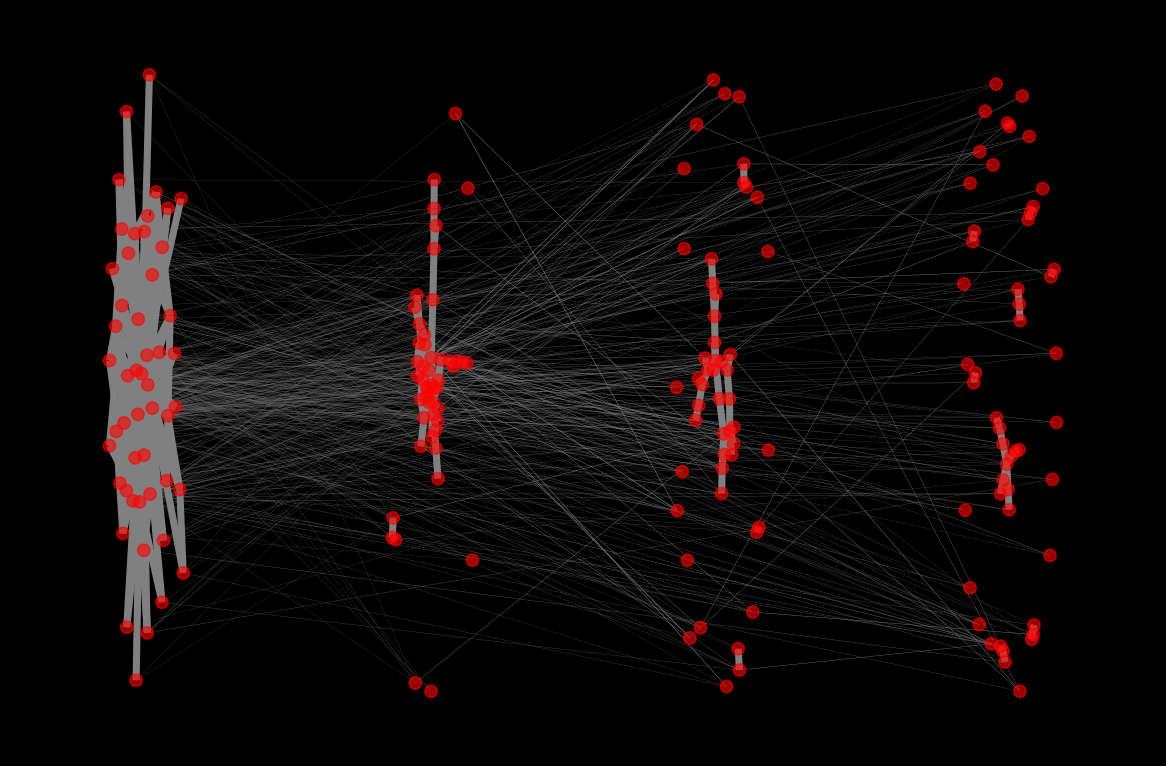

B_max = undefined
xatol = 1e-4
fatol = 1e-4
maxiter = 300
maxfev = default
mean J0 intra = 0.9984131472603486
r_intra = 7.2514165309320295e-06
r_inter = 0.010170693138345267
F_w = 0.30512804556688894


In [22]:
# Clustering protocol
def optimize_clustering(G, n_clusters=4, w=30.0, seed=42):
    nodes = list(G.nodes())
    N = len(nodes)
    clusters = np.array_split(nodes, n_clusters)
    clusters = [list(cluster) for cluster in clusters]
    node_to_cluster = {}
    for cid, cluster in enumerate(clusters):
        for node in cluster:
            node_to_cluster[node] = cid
    smart_x0_full = np.array([0.1, 2.4048 + 0.3, 5.5201 - 0.4, 8.6537 + 0.2])
    smart_x0_full = smart_x0_full - smart_x0_full[0]
    if n_clusters != 4:
        smart_x0_full = np.linspace(0.0, 2.4048 * (n_clusters - 1), n_clusters)
    smart_x0 = smart_x0_full[1:]
    rng = np.random.default_rng(seed)
    noise_opt = {
        cid: rng.normal(0, 0.04, size=len(cluster))
        for cid, cluster in enumerate(clusters)}

    def unpack_B_means(x):
        return np.concatenate(([0.0], x))
    def build_B_temp(B_means, noise_dict):
        B_temp = {}
        for cid, cluster in enumerate(clusters):
            for local_idx, node in enumerate(cluster):
                B_temp[node] = B_means[cid] + noise_dict[cid][local_idx]
        return B_temp
    def same_cluster(i, j):
        return node_to_cluster[i] == node_to_cluster[j]
    def loss_function_fixed(x):
        B_means = unpack_B_means(x)
        B_temp = build_B_temp(B_means, noise_opt)
        intra = 0.0
        inter = 0.0
        intra_cnt = 0
        inter_cnt = 0
        for i, j in G.edges():
            diff = B_temp[i] - B_temp[j]
            value = j0(diff)
            if same_cluster(i, j):
                intra += (1 - value) ** 2
                intra_cnt += 1
            else:
                inter += value ** 2
                inter_cnt += 1
        intra_cnt = max(intra_cnt, 1)
        inter_cnt = max(inter_cnt, 1)
        return (intra / intra_cnt) + w * (inter / inter_cnt)
    print(f"Running 10 Nelder-Mead attempts for clustering with {n_clusters} clusters")
    print(f"Number of nodes: {N}")
    print("Cluster sizes:", [len(cluster) for cluster in clusters])

    best_loss = np.inf
    best_x = None
    for attempt in range(10):
        x0 = smart_x0 + rng.normal(0, 0.8, size=n_clusters - 1)
        res = minimize(loss_function_fixed, x0, method="Nelder-Mead", options={"maxiter": 300, "xatol": XATOL, "fatol": FATOL})
        print(attempt, "loss =", res.fun)
        if res.fun < best_loss:
            best_loss = res.fun
            best_x = res.x.copy()
    optimal_B_means = unpack_B_means(best_x)
    print("Optimal B means:", np.round(optimal_B_means, 4))
    print("Final objective:", best_loss)

    rng_final = np.random.default_rng(123)
    B_cluster = {}
    for cid, cluster in enumerate(clusters):
        noise = rng_final.normal(0, 0.06, size=len(cluster))
        for local_idx, node in enumerate(cluster):
            B_cluster[node] = optimal_B_means[cid] + noise[local_idx]
    first_node = nodes[0]
    gauge_shift = B_cluster[first_node]
    for node in nodes:
        B_cluster[node] -= gauge_shift
    return B_cluster, clusters, best_loss

def draw_clustered_graph(G, clusters, B_values, scale_edges=5, node_size=80):
    pos = {}
    spacing = 6
    for cid, cluster in enumerate(clusters):
        subG = G.subgraph(cluster)
        local_pos = nx.spring_layout(subG, seed=42)
        cx, cy = cid * spacing, 0
        for node in cluster:
            pos[node] = local_pos[node] + np.array([cx, cy])
    node_colors = ["red" for _ in G.nodes()]
    edges = []
    widths = []
    eps = 0.1
    for i, j in G.edges():
        weight = j0(B_values[i] - B_values[j]) ** 2
        edges.append((i, j))
        widths.append(scale_edges * weight + eps)
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size, alpha=0.6)
    nx.draw_networkx_edges( G, pos, edgelist=edges, width=widths, edge_color="gray", alpha=1)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

B_CLUSTER, CLUSTERS, CLUSTER_OBJECTIVE = optimize_clustering(G_SF, n_clusters=4, w=30.0)
draw_clustered_graph( G_SF, CLUSTERS, B_CLUSTER)
intra_vals = []
inter_vals = []

for i, j in G_SF.edges():
    value = j0(B_CLUSTER[i] - B_CLUSTER[j])

    if i // 50 == j // 50:
        intra_vals.append(value)
    else:
        inter_vals.append(value)

intra_vals = np.array(intra_vals)
inter_vals = np.array(inter_vals)

r_intra = np.mean((1 - intra_vals) ** 2)
r_inter = np.mean(inter_vals ** 2)
F_w = r_intra + 30 * r_inter

print("B_max = undefined")
print("xatol = 1e-4")
print("fatol = 1e-4")
print("maxiter = 300")
print("maxfev = default")
print("mean J0 intra =", np.mean(intra_vals))
print("r_intra =", r_intra)
print("r_inter =", r_inter)
print("F_w =", F_w)

B_table = np.array([
    [int(i), float(B_CLUSTER[i])]
    for i in sorted(B_CLUSTER.keys())
])

np.savetxt(
    "B_claster_final.txt",
    B_table,
    fmt=["%d", "%.10f"],
    header="node B_i",
    comments=""
)